In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         SPAI — Complete Fixed Training Script for Kaggle T4     ║
# ║  Paste each cell block into a separate Kaggle notebook cell     ║
# ╚══════════════════════════════════════════════════════════════════╝

# ═══════════════════════════════════════════════════════════════════
# CELL 1 — Imports & GPU check
# ═══════════════════════════════════════════════════════════════════
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import io
import time
import pathlib
from pathlib import Path
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


In [2]:
def make_frequency_mask(H: int, W: int, r: int = 16) -> torch.Tensor:
    cH, cW = H // 2, W // 2
    ys   = torch.arange(H).unsqueeze(1).expand(H, W)
    xs   = torch.arange(W).unsqueeze(0).expand(H, W)
    dist = torch.sqrt((ys - cH).float()**2 + (xs - cW).float()**2)
    return (dist >= r).float()


def frequency_decompose(x: torch.Tensor, r: int = 16):
    """x: (C,H,W) on any device — mask follows automatically."""
    C, H, W    = x.shape
    chi        = torch.fft.fft2(x)
    chi_shifted = torch.fft.fftshift(chi)
    M          = make_frequency_mask(H, W, r=r).to(x.device)   # ← device fix
    x_high     = torch.fft.ifft2(torch.fft.ifftshift(chi_shifted * M)).real
    x_low      = torch.fft.ifft2(torch.fft.ifftshift(chi_shifted * (1 - M))).real
    return x_high, x_low


# quick sanity check
_x = torch.rand(3, 224, 224)
_xh, _xl = frequency_decompose(_x)
assert (_xh + _xl - _x).abs().max() < 1e-5, "decompose failed"
print("Frequency decompose ✅")

Frequency decompose ✅


In [3]:
%pip install -q timm==0.4.12 tabulate yacs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 6.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


```

---

#### 🔹 Shape Check
```
Input shape:          torch.Size([3, 224, 224])
High-freq shape:      torch.Size([3, 224, 224])
Low-freq shape:       torch.Size([3, 224, 224])
Max reconstruction error: ~1e-6  ✅ (floating point only)

In [4]:
import timm
 
class MFMBackbone(nn.Module):
    def __init__(
        self,
        pretrained:      bool        = True,
        model_name:      str         = "vit_base_patch16_224",
        checkpoint_path: str | None  = "/kaggle/input/models/babykamal/spai/pytorch/default/1/spai.pth",
    ):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        if checkpoint_path is not None:
            self._load_checkpoint(checkpoint_path)
        self.N = 12
        self.d = 768
        self.p = 16
        self._block_outputs = {}
        for n, block in enumerate(self.vit.blocks):
            block.register_forward_hook(self._make_hook(n))
 
    def _load_checkpoint(self, checkpoint_path: str) -> None:
        ckpt_path = pathlib.Path(checkpoint_path)
        if not ckpt_path.is_file():
            print(f"Checkpoint not found, skipping: {ckpt_path}")
            return
        checkpoint  = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        state_dict  = checkpoint['model']
        vit_weights = {
            k.replace("mfvit.vit.", ""): v
            for k, v in state_dict.items()
            if k.startswith("mfvit.vit.")
        }
        model_state   = self.vit.state_dict()
        fixed_weights = {
            k: v for k, v in vit_weights.items()
            if k in model_state and model_state[k].shape == v.shape
        }
        for i in range(12):
            q_key, v_key = f"blocks.{i}.attn.q_bias", f"blocks.{i}.attn.v_bias"
            target       = f"blocks.{i}.attn.qkv.bias"
            if q_key in vit_weights and v_key in vit_weights:
                q = vit_weights[q_key]
                fixed_weights[target] = torch.cat([q, torch.zeros_like(q), vit_weights[v_key]])
        msg = self.vit.load_state_dict(fixed_weights, strict=False)
        print(f"Loaded {len(fixed_weights)} keys | "
              f"Missing {len(msg.missing_keys)} (final norm — OK)")
 
    def _make_hook(self, n: int):
        def hook(module, input, output):
            self._block_outputs[n] = output
        return hook
 
    def forward(self, x: torch.Tensor) -> dict:
        self._block_outputs = {}
        _ = self.vit(x)
        return {n: feat[:, 1:, :] for n, feat in self._block_outputs.items()}
 
    def freeze(self):
        for p in self.vit.parameters():
            p.requires_grad = False
        print("Backbone frozen ✅")

In [5]:
def prepare_for_vit(img: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.485, 0.456, 0.406], device=img.device).view(-1,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=img.device).view(-1,1,1)
    return (img.clamp(0, 1) - mean) / std
 
 
class SpectralEncoder(nn.Module):
    def __init__(self, backbone: MFMBackbone, r: int = 16):
        super().__init__()
        self.backbone = backbone
        self.r        = r
 
    def forward(self, x: torch.Tensor):
        B = x.shape[0]
        x_high_list, x_low_list = [], []
        for i in range(B):
            xh, xl = frequency_decompose(x[i], r=self.r)
            x_high_list.append(xh)
            x_low_list.append(xl)
        x_high = torch.stack(x_high_list)
        x_low  = torch.stack(x_low_list)
        x_cat  = torch.cat([
            prepare_for_vit(x),
            prepare_for_vit(x_low),
            prepare_for_vit(x_high),
        ], dim=0)                              # (3B, C, H, W)
        with torch.no_grad():
            all_blocks = self.backbone(x_cat)
        z, z_l, z_h = {}, {}, {}
        for n, feat in all_blocks.items():
            z[n]   = feat[:B]
            z_l[n] = feat[B:2*B]
            z_h[n] = feat[2*B:]
        return z, z_l, z_h

In [6]:
class ProjectionOperator(nn.Module):
    def __init__(self, d_in: int = 768, d_out: int = 1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d_in),
            nn.Linear(d_in, d_out),
            nn.GELU(),
            nn.Linear(d_out, d_out),
            nn.LayerNorm(d_out),
        )
    def forward(self, x): return self.net(x)
 
 
class ProjectionBank(nn.Module):
    def __init__(self, N: int = 12, d: int = 768, D: int = 1024):
        super().__init__()
        self.N          = N
        self.projectors = nn.ModuleList([ProjectionOperator(d, D) for _ in range(N)])
 
    def forward(self, z, z_l, z_h):
        z_bar, z_bar_l, z_bar_h = {}, {}, {}
        for n, proj in enumerate(self.projectors):
            B        = z[n].shape[0]
            stacked  = torch.cat([z[n], z_l[n], z_h[n]], dim=0)
            proj_out = proj(stacked)
            z_bar[n]   = proj_out[:B]
            z_bar_l[n] = proj_out[B:2*B]
            z_bar_h[n] = proj_out[2*B:]
        return z_bar, z_bar_l, z_bar_h
 
 

In [7]:
class SpectralReconstructionSimilarity(nn.Module):
    def __init__(self, N: int = 12):
        super().__init__()
        self.N = N
 
    def forward(self, z_bar, z_bar_l, z_bar_h) -> torch.Tensor:
        all_stats = []
        for n in range(self.N):
            za, za_l, za_h = z_bar[n], z_bar_l[n], z_bar_h[n]
            omega_ol = F.cosine_similarity(za,   za_l, dim=-1)
            omega_oh = F.cosine_similarity(za,   za_h, dim=-1)
            omega_lh = F.cosine_similarity(za_l, za_h, dim=-1)
            block_stats = torch.stack([
                omega_ol.mean(-1), omega_ol.std(-1),
                omega_oh.mean(-1), omega_oh.std(-1),
                omega_lh.mean(-1), omega_lh.std(-1),
            ], dim=-1)
            all_stats.append(block_stats)
        return torch.cat(all_stats, dim=-1)   # (B, 6N)

In [8]:
class TwoLayerProjection(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_out), nn.GELU(),
            nn.Linear(d_out, d_out), nn.LayerNorm(d_out),
        )
    def forward(self, x): return self.net(x)
 
 
class SpectralContextVector(nn.Module):
    def __init__(self, N: int = 12, D: int = 1024):
        super().__init__()
        self.N  = N
        self.D  = D
        self.C  = nn.Parameter(torch.randn(N, D))
        self.P1 = TwoLayerProjection(2*D, D)
        self.P2 = TwoLayerProjection(D,   D)
 
    def forward(self, z_bar) -> torch.Tensor:
        block_stats = []
        for n in range(self.N):
            feat = z_bar[n]
            block_stats.append(torch.cat([feat.mean(1), feat.std(1)], dim=-1))
        z_prime      = torch.stack(block_stats, dim=1)        # (B, N, 2D)
        z_prime_proj = self.P1(z_prime)                       # (B, N, D)
        C_soft       = torch.softmax(self.C, dim=0).unsqueeze(0)
        C_prime      = self.P2(C_soft * z_prime_proj)         # (B, N, D)
        return C_prime.sum(dim=1)                             # (B, D)
 

In [9]:
class SpectralVectorAssembly(nn.Module):
    def __init__(self, D: int = 1024, N: int = 12):
        super().__init__()
        self.out_dim = D + 6 * N
 
    def forward(self, z_C, z_lambda):
        return torch.cat([z_C, z_lambda], dim=-1)
 

In [10]:
class SpectralContextAttention(nn.Module):
    def __init__(self, d_s: int = 1096, Dh: int = 1536):
        super().__init__()
        self.scale = Dh ** -0.5
        self.q     = nn.Parameter(torch.randn(Dh))
        self.WK    = nn.Linear(d_s, Dh,  bias=False)
        self.WV    = nn.Linear(d_s, Dh,  bias=False)
        self.WO    = nn.Linear(Dh,  d_s, bias=False)
 
    def forward(self, z_bar_S):
        B        = z_bar_S.shape[0]
        K_proj   = self.WK(z_bar_S)                                      # (B,K,Dh)
        V_proj   = self.WV(z_bar_S)                                      # (B,K,Dh)
        q        = self.q.unsqueeze(0).unsqueeze(0).expand(B, 1, -1)     # (B,1,Dh)
        A        = torch.softmax(
            torch.matmul(q, K_proj.transpose(1,2)) * self.scale, dim=-1  # (B,1,K)
        )
        z_att    = torch.matmul(A, V_proj).squeeze(1)                    # (B,Dh)
        return self.WO(z_att), A.squeeze(1)                              # (B,d_s),(B,K)
 

In [11]:
class ClassificationHead(nn.Module):
    def __init__(self, d_s: int = 1096):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_s, 512), nn.ReLU(),
            nn.Linear(512, 128), nn.ReLU(),
            nn.Linear(128, 1),
            # NO Sigmoid — BCEWithLogitsLoss handles it numerically safely
        )
    def forward(self, z_S):
        return self.mlp(z_S).squeeze(-1)    # raw logit (B,)
 
 

In [12]:
def compute_patch_spectral_vector(patch, encoder, proj_bank, srs, scv, assembler):
    z, z_l, z_h             = encoder(patch)
    z_bar, z_bar_l, z_bar_h = proj_bank(z, z_l, z_h)
    z_lambda                 = srs(z_bar, z_bar_l, z_bar_h)
    z_C                      = scv(z_bar)
    return assembler(z_C, z_lambda)
 
 
class SPAI(nn.Module):
    def __init__(
        self,
        checkpoint_path: str | None = None,
        N=12, d=768, D=1024, Dh=1536, r=16, patch_size=224,
    ):
        super().__init__()
        self.patch_size = patch_size
        d_s             = D + 6 * N   # 1096
 
        self.backbone  = MFMBackbone(pretrained=True, checkpoint_path=checkpoint_path)
        self.backbone.freeze()
        self.encoder   = SpectralEncoder(self.backbone, r=r)
        self.proj_bank = ProjectionBank(N=N, d=d, D=D)
        self.srs       = SpectralReconstructionSimilarity(N=N)
        self.scv       = SpectralContextVector(N=N, D=D)
        self.assembler = SpectralVectorAssembly(D=D, N=N)
        self.sca       = SpectralContextAttention(d_s=d_s, Dh=Dh)
        self.clf       = ClassificationHead(d_s=d_s)
 
 
class SPAITrainable(nn.Module):
    """Wraps SPAI for K-view training."""
    def __init__(self, spai: SPAI):
        super().__init__()
        self.spai = spai
 
    def forward(self, views: torch.Tensor) -> torch.Tensor:
        """views: (B, K, 3, 224, 224) → logits (B,)"""
        B, K = views.shape[:2]
        patch_vectors = []
        for k in range(K):
            z_S_k = compute_patch_spectral_vector(
                views[:, k],
                self.spai.encoder, self.spai.proj_bank,
                self.spai.srs,     self.spai.scv,
                self.spai.assembler,
            )
            patch_vectors.append(z_S_k)
        z_bar_S   = torch.stack(patch_vectors, dim=1)   # (B, K, 1096)
        z_S, _    = self.spai.sca(z_bar_S)
        return self.spai.clf(z_S)                        # raw logit (B,)
 
 

In [13]:
@torch.no_grad()
def spai_inference(image_input, model, patch_size=224, device='cpu'):
    model.eval()
    model.to(device)
 
    pil_img = Image.open(image_input).convert('RGB') \
              if isinstance(image_input, str) else image_input.convert('RGB')
 
    W = (pil_img.width  // patch_size) * patch_size
    H = (pil_img.height // patch_size) * patch_size
    if W == 0 or H == 0:
        pil_img = pil_img.resize((patch_size, patch_size))
        W, H = patch_size, patch_size
    else:
        pil_img = pil_img.resize((W, H))
 
    x       = TF.to_tensor(pil_img).unsqueeze(0).to(device)
    patches, positions = [], []
    for i in range(0, H, patch_size):
        for j in range(0, W, patch_size):
            patches.append(x[:, :, i:i+patch_size, j:j+patch_size])
            positions.append((i, j))
 
    patch_vectors = [
        compute_patch_spectral_vector(
            p, model.encoder, model.proj_bank,
            model.srs, model.scv, model.assembler,
        ) for p in patches
    ]
    z_bar_S   = torch.stack(patch_vectors, dim=1)
    z_S, attn = model.sca(z_bar_S)
    logit     = model.clf(z_S)
    score     = torch.sigmoid(logit).item()    # ← sigmoid here
 
    return {
        'score':      score,
        'is_fake':    score > 0.5,
        'label':      f"AI-Generated ({score:.1%})" if score > 0.5
                      else f"Real ({1-score:.1%})",
        'attn':       attn[0].cpu(),
        'positions':  positions,
        'image_size': (H, W),
        'n_patches':  len(patches),
        'grid_shape': (H // patch_size, W // patch_size),
    }
 
 

In [14]:
FAKE_ROOT  = Path("/kaggle/input/datasets/aryankaushik005/custom-dataset/content/fake_images")
REAL_TRAIN = Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/train2017")
REAL_VAL   = Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017")
CKPT_PATH  = "/kaggle/input/models/babykamal/spai/pytorch/default/1/spai.pth"
SAVE_DIR   = "/kaggle/working/checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
 
TRAIN_GENERATORS = ['latent_diffusion', 'stable_diffusion', 'ddpm', 'palette']
EVAL_GENERATORS  = [
    'big_gan', 'denoising_diffusion_gan', 'diffusion_gan',
    'face_synthetics', 'gansformer', 'glide', 'projected_gan',
    'sfhq', 'star_gan', 'stylegan1', 'stylegan2', 'stylegan3',
    'taming_transformer', 'vq_diffusion', 'generative_inpainting',
    'lama', 'mat',
]
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}
 
 
def collect_images(folder: Path, max_images: int = None) -> list:
    paths = [str(p) for p in folder.rglob('*') if p.suffix.lower() in EXTENSIONS]
    if max_images and len(paths) > max_images:
        random.shuffle(paths)
        paths = paths[:max_images]
    return paths
 
 
def build_file_lists(
    max_real_train=10000, max_real_val=2000,
    max_fake_train=10000, max_fake_val=2000,
):
    real_train = collect_images(REAL_TRAIN, max_real_train)
    real_val   = collect_images(REAL_VAL,   max_real_val)
    print(f"Real  train={len(real_train)} | val={len(real_val)}")
 
    fake_train, fake_val = [], []
    per_gen = max(max_fake_train // max(len(TRAIN_GENERATORS), 1), 1)
    for gen in TRAIN_GENERATORS:
        gp = FAKE_ROOT / gen
        if not gp.exists():
            print(f"  skip (not found): {gen}")
            continue
        paths = collect_images(gp, per_gen + 200)
        split = int(len(paths) * 0.9)
        fake_train.extend(paths[:split])
        fake_val.extend(paths[split:])
        print(f"  {gen:25s}: {split} train + {len(paths)-split} val")
 
    print(f"Fake  train={len(fake_train)} | val={len(fake_val)}")
 
    train_s = [(p, 0.) for p in real_train] + [(p, 1.) for p in fake_train]
    val_s   = [(p, 0.) for p in real_val]   + [(p, 1.) for p in fake_val]
    random.shuffle(train_s)
    random.shuffle(val_s)
    print(f"Total train={len(train_s)} | val={len(val_s)}")
    return train_s, val_s
 
 
class SPAIDataset(Dataset):
    def __init__(self, samples, K=4, patch_size=224, augment=True):
        self.samples    = samples
        self.K          = K
        self.patch_size = patch_size
        self.augment    = augment
 
    def _augment_view(self, img):
        view = transforms.Compose([
            transforms.RandomResizedCrop(
                self.patch_size, scale=(0.5, 1.0), ratio=(0.75, 1.333),
                interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
        ])(img)
        view = TF.to_tensor(view)
        r = random.random()
        if r < 0.35:
            buf = io.BytesIO()
            TF.to_pil_image(view.clamp(0,1)).save(
                buf, format='JPEG', quality=random.randint(50, 95))
            buf.seek(0)
            view = TF.to_tensor(Image.open(buf))
        elif r < 0.55:
            view = transforms.GaussianBlur(random.choice([3,5]), (0.1,2.0))(view)
        elif r < 0.70:
            view = (view + torch.randn_like(view)*random.uniform(1,5)/255).clamp(0,1)
        return view
 
    def _val_view(self, img):
        return transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(self.patch_size),
            transforms.ToTensor(),
        ])(img)
 
    def __len__(self): return len(self.samples)
 
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.fromarray(
                np.random.randint(0, 255, (256,256,3), dtype=np.uint8))
        if self.augment:
            views = torch.stack([self._augment_view(img) for _ in range(self.K)])
        else:
            v     = self._val_view(img)
            views = v.unsqueeze(0).expand(self.K,-1,-1,-1).clone()
        return views, torch.tensor(label, dtype=torch.float32)
 

In [15]:
class MetricTracker:
    def __init__(self): self.reset()
    def reset(self):
        self.losses = []; self.preds = []; self.labels = []
    def update(self, loss, y_hat, y):
        self.losses.append(loss)
        self.preds.extend(y_hat.detach().cpu().tolist())
        self.labels.extend(y.detach().cpu().tolist())
    def compute(self):
        probs     = torch.sigmoid(torch.tensor(self.preds)).tolist()
        preds_bin = [1 if p > 0.5 else 0 for p in probs]
        acc = accuracy_score(self.labels, preds_bin)
        try:    auc = roc_auc_score(self.labels, probs)
        except: auc = 0.5
        return {'loss': float(np.mean(self.losses)), 'acc': acc, 'auc': auc}
 
 
def build_scheduler(optimizer, warmup_epochs, total_epochs,
                    steps_per_epoch, lr_max=5e-4, lr_min=2.5e-7):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps  = total_epochs  * steps_per_epoch
    def lr_lambda(step):
        if step < warmup_steps:
            alpha = (step+1) / warmup_steps
            return (lr_min + alpha*(lr_max-lr_min)) / lr_max
        progress = (step-warmup_steps) / max(total_steps-warmup_steps, 1)
        cosine   = 0.5*(1 + np.cos(np.pi*progress))
        return (lr_min + cosine*(lr_max-lr_min)) / lr_max
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
 
 
def train_spai(
    model,
    train_samples, val_samples,
    resume_path   = None,
    epochs        = 10,      # start small — change to 35 for full run
    batch_size    = 8,       # T4-safe; increase to 16 if no OOM
    lr            = 5e-4,
    warmup_epochs = 2,       # proportional to epochs
    K             = 4,
    num_workers   = 2,
    device        = 'cuda' if torch.cuda.is_available() else 'cpu',
):
    train_ds = SPAIDataset(train_samples, K=K, augment=True)
    val_ds   = SPAIDataset(val_samples,   K=K, augment=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
 
    model     = model.to(device)
    criterion = nn.BCEWithLogitsLoss()            # ← KEY FIX
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=0.05, betas=(0.9, 0.999))
    scheduler = build_scheduler(optimizer, warmup_epochs, epochs, len(train_loader))
    scaler    = torch.amp.GradScaler('cuda', enabled=(device=='cuda'))  # ← updated API
 
    start_epoch   = 1
    history       = []
    best_val_loss = float('inf')
 
    # Resume from checkpoint if provided
    if resume_path and os.path.exists(resume_path):
        ckpt        = torch.load(resume_path, map_location='cpu')
        model.load_state_dict(ckpt['model'])
        start_epoch = ckpt['epoch'] + 1
        history     = ckpt.get('history', [])
        best_val_loss = ckpt.get('val_loss', float('inf'))
        # Fast-forward scheduler
        for _ in range((start_epoch-1) * len(train_loader)):
            scheduler.step()
        print(f"Resumed from epoch {start_epoch-1} "
              f"(best val_loss={best_val_loss:.4f})")
 
    print(f"\n{'='*65}")
    print(f"Device={device} | Train={len(train_ds)} | Val={len(val_ds)}")
    print(f"Batch={batch_size} | Epochs={epochs} | LR={lr}")
    print(f"{'='*65}\n")
 
    for epoch in range(start_epoch, epochs+1):
        t0 = time.time()
 
        # ── Train ──────────────────────────────────────────────────
        model.train()
        trk = MetricTracker()
        for views, labels in train_loader:
            views, labels = views.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device=='cuda')):  # ← updated
                y_hat = model(views)              # raw logit
                loss  = criterion(y_hat, labels)  # BCEWithLogitsLoss
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            trk.update(loss.item(), y_hat, labels)
 
        # ── Validate ───────────────────────────────────────────────
        model.eval()
        val_trk = MetricTracker()
        with torch.no_grad():
            for views, labels in val_loader:
                views, labels = views.to(device), labels.to(device)
                with torch.amp.autocast('cuda', enabled=(device=='cuda')):
                    y_hat = model(views)
                    loss  = criterion(y_hat, labels)
                val_trk.update(loss.item(), y_hat, labels)
 
        tm, vm = trk.compute(), val_trk.compute()
        cur_lr = optimizer.param_groups[0]['lr']
        elapsed = time.time() - t0
 
        log = {
            'epoch': epoch,
            'train_loss': tm['loss'], 'train_acc': tm['acc'], 'train_auc': tm['auc'],
            'val_loss':   vm['loss'], 'val_acc':   vm['acc'], 'val_auc':   vm['auc'],
            'lr': cur_lr,
        }
        history.append(log)
 
        print(f"Epoch {epoch:2d}/{epochs} [{elapsed:.0f}s] | "
              f"Train loss={tm['loss']:.4f} acc={tm['acc']:.3f} auc={tm['auc']:.3f} | "
              f"Val loss={vm['loss']:.4f} acc={vm['acc']:.3f} auc={vm['auc']:.3f} | "
              f"lr={cur_lr:.2e}")
 
        # Save latest every epoch (for resuming next Kaggle session)
        torch.save({'epoch': epoch, 'model': model.state_dict(),
                    'val_loss': vm['loss'], 'history': history},
                   f"{SAVE_DIR}/spai_latest.pth")
 
        if vm['loss'] < best_val_loss:
            best_val_loss = vm['loss']
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'val_loss': vm['loss'], 'val_auc': vm['auc'],
                        'history': history},
                       f"{SAVE_DIR}/spai_best.pth")
            print(f"  → ✅ Best saved (val_loss={vm['loss']:.4f} auc={vm['auc']:.3f})")
 
    return model, history

Real  train=5000 | val=1000
  latent_diffusion         : 1305 train + 145 val
  stable_diffusion         : 1305 train + 145 val
  ddpm                     : 134 train + 15 val
  palette                  : 900 train + 100 val
Fake  train=3644 | val=405
Total train=8644 | val=1405
Loaded 148 keys | Missing 2 (final norm — OK)
Backbone frozen ✅
Frozen=85,798,656 | Trainable=33,030,401

*** PILOT RUN — 3 epochs to verify pipeline ***

Device=cuda | Train=8644 | Val=1405
Batch=8 | Epochs=3 | LR=0.0005

Epoch  1/3 [997s] | Train loss=0.4441 acc=0.839 auc=0.913 | Val loss=0.3974 acc=0.920 auc=0.977 | lr=5.00e-04
  → ✅ Best saved (val_loss=0.3974 auc=0.977)
Epoch  2/3 [1008s] | Train loss=0.1912 acc=0.947 auc=0.984 | Val loss=0.0658 acc=0.984 auc=0.998 | lr=2.50e-04
  → ✅ Best saved (val_loss=0.0658 auc=0.998)
Epoch  3/3 [1008s] | Train loss=0.0639 acc=0.981 auc=0.998 | Val loss=0.0584 acc=0.986 auc=0.998 | lr=2.50e-07
  → ✅ Best saved (val_loss=0.0584 auc=0.998)


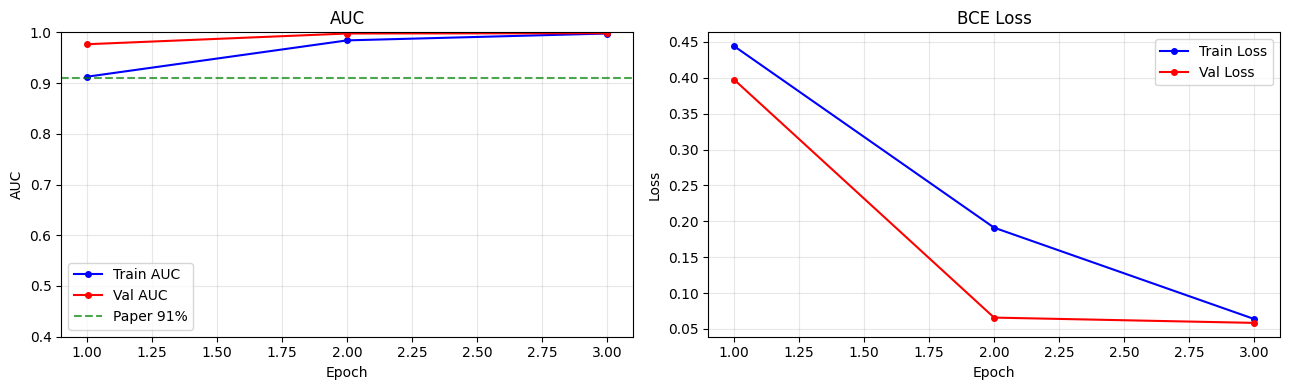

Saved → /kaggle/working/spai_curves.png

EVALUATION PER GENERATOR
Scoring 100 real images...
Real → mean=0.012 std=0.099

Generator                 |    AUC |     AP |    Acc | n_fake
────────────────────────────────────────────────────────────
big_gan                   |  99.5% |  99.6% |  97.5% | 100
denoising_diffusion_gan   | 100.0% | 100.0% |  99.5% | 100
diffusion_gan             |  99.8% |  99.8% |  97.5% | 100
face_synthetics           |  99.1% |  99.1% |  92.0% | 100
gansformer                | 100.0% | 100.0% |  99.5% | 100
glide                     |  99.7% |  99.7% |  96.0% | 100
projected_gan             |  99.5% |  99.5% |  95.5% | 100
sfhq                      |  99.9% |  99.9% |  99.0% | 100
star_gan                  | 100.0% | 100.0% |  99.5% | 100
stylegan1                 | 100.0% | 100.0% |  99.5% | 100
stylegan2                 |  99.7% |  99.7% |  98.0% | 100
stylegan3                 |  99.9% |  99.9% |  99.0% | 100
taming_transformer        |  99.8% |  99.8% |  

In [16]:
@torch.no_grad()
def evaluate_per_generator(
    model, real_paths,
    device      = 'cuda' if torch.cuda.is_available() else 'cpu',
    max_per_gen = 200,
    patch_size  = 224,
):
    model.eval()
    model.to(device)
    spai_core = model.spai if hasattr(model, 'spai') else model
 
    print(f"\n{'='*65}\nEVALUATION PER GENERATOR\n{'='*65}")
    print(f"Scoring {min(len(real_paths), max_per_gen)} real images...")
 
    real_scores = []
    for p in real_paths[:max_per_gen]:
        try:
            s = spai_inference(p, spai_core, patch_size=patch_size, device=device)['score']
            real_scores.append(s)
        except Exception:
            continue
    print(f"Real → mean={np.mean(real_scores):.3f} std={np.std(real_scores):.3f}")
 
    print(f"\n{'Generator':25s} | {'AUC':>6} | {'AP':>6} | {'Acc':>6} | n_fake")
    print("─" * 60)
 
    all_results = {}
    for gen in EVAL_GENERATORS:
        gen_path = FAKE_ROOT / gen
        if not gen_path.exists():
            continue
        fake_paths = collect_images(gen_path, max_per_gen)
        fake_scores = []
        for p in fake_paths:
            try:
                s = spai_inference(p, spai_core, patch_size=patch_size, device=device)['score']
                fake_scores.append(s)
            except Exception:
                continue
        if not fake_scores: continue
 
        scores = real_scores + fake_scores
        labels = [0]*len(real_scores) + [1]*len(fake_scores)
        if len(set(labels)) < 2: continue
 
        auc = roc_auc_score(labels, scores)  * 100
        ap  = average_precision_score(labels, scores) * 100
        acc = accuracy_score(labels, [1 if s>0.5 else 0 for s in scores]) * 100
        all_results[gen] = {'auc': auc, 'ap': ap, 'acc': acc}
        print(f"{gen:25s} | {auc:5.1f}% | {ap:5.1f}% | {acc:5.1f}% | {len(fake_scores)}")
 
    if all_results:
        avg_auc = np.mean([v['auc'] for v in all_results.values()])
        print("─"*60)
        print(f"{'AVERAGE':25s} | {avg_auc:5.1f}%")
        print(f"Paper reports 91.0% — your result: {avg_auc:.1f}%")
    return all_results
 
 
# ═══════════════════════════════════════════════════════════════════
# CELL 17 — Plot training curves
# ═══════════════════════════════════════════════════════════════════
def plot_history(history):
    epochs     = [h['epoch']      for h in history]
    train_auc  = [h['train_auc']  for h in history]
    val_auc    = [h['val_auc']    for h in history]
    train_loss = [h['train_loss'] for h in history]
    val_loss   = [h['val_loss']   for h in history]
 
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, train_auc,  'b-o', ms=4, label='Train AUC')
    axes[0].plot(epochs, val_auc,    'r-o', ms=4, label='Val AUC')
    axes[0].axhline(0.91, color='green', ls='--', label='Paper 91%', alpha=0.7)
    axes[0].set(title='AUC', xlabel='Epoch', ylabel='AUC')
    axes[0].set_ylim(0.4, 1.0); axes[0].legend(); axes[0].grid(alpha=0.3)
 
    axes[1].plot(epochs, train_loss, 'b-o', ms=4, label='Train Loss')
    axes[1].plot(epochs, val_loss,   'r-o', ms=4, label='Val Loss')
    axes[1].set(title='BCE Loss', xlabel='Epoch', ylabel='Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)
 
    plt.tight_layout()
    plt.savefig('/kaggle/working/spai_curves.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved → /kaggle/working/spai_curves.png")
 
 
# ═══════════════════════════════════════════════════════════════════
# CELL 18 — RUN  (small pilot first, then scale up)
# ═══════════════════════════════════════════════════════════════════
 
# ── Build dataset ─────────────────────────────────────────────────
train_samples, val_samples = build_file_lists(
    max_real_train = 5000,   # pilot: small & fast
    max_real_val   = 1000,
    max_fake_train = 5000,
    max_fake_val   = 1000,
)
 
# ── Build model ───────────────────────────────────────────────────
spai_base  = SPAI(checkpoint_path=CKPT_PATH)
spai_model = SPAITrainable(spai_base)
 
frozen    = sum(p.numel() for p in spai_model.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in spai_model.parameters() if p.requires_grad)
print(f"Frozen={frozen:,} | Trainable={trainable:,}")
 
# ── PILOT TRAINING (3 epochs, verify everything works) ────────────
print("\n*** PILOT RUN — 3 epochs to verify pipeline ***")
trained_model, history = train_spai(
    model         = spai_model,
    train_samples = train_samples,
    val_samples   = val_samples,
    resume_path   = None,          # set to f"{SAVE_DIR}/spai_latest.pth" to resume
    epochs        = 3,             # ← pilot: 3 epochs (~15-20 min on T4)
    batch_size    = 8,             # ← safe for T4 16GB
    lr            = 5e-4,
    warmup_epochs = 1,
    K             = 4,
    num_workers   = 2,
)
 
# ── Plot pilot curves ─────────────────────────────────────────────
plot_history(history)
 
# ── If pilot works, scale up by changing these values: ────────────
# epochs=35, batch_size=16, max_real_train=20000, max_fake_train=10000
# Then for next Kaggle session set resume_path=f"{SAVE_DIR}/spai_latest.pth"
 
# ── Evaluate on unseen generators ─────────────────────────────────
real_eval = collect_images(REAL_VAL, max_images=300)
results   = evaluate_per_generator(
    model       = trained_model,
    real_paths  = real_eval,
    max_per_gen = 100,    # fast eval
)

In [17]:
# ═══════════════════════════════════════════════════════════════════
# PROPER EVALUATION — mirrors Table 1 of the paper
# Uses 5 sources of real images × 17 generators
# ═══════════════════════════════════════════════════════════════════

import requests
import zipfile
from sklearn.metrics import roc_auc_score, accuracy_score, average_precision_score

# ── Real image sources (download small subsets) ───────────────────

# Source 1: COCO val (already have this)
COCO_VAL = Path("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017")

# Source 2: ImageNet val (already in Kaggle)
# Add this dataset to your notebook:
# kaggle datasets add -d ifigotin/imagenetmini-1000
IMAGENET_VAL = Path("/kaggle/input/imagenetmini-1000/imagenet-mini/val")

# Source 3-5: Download from web (small subsets)
def download_real_images():
    """Download small subsets of real image datasets."""
    save_dir = Path("/kaggle/working/real_images")
    save_dir.mkdir(exist_ok=True)

    # We'll use COCO and ImageNet we already have
    # Plus generate some from Kaggle's available datasets
    sources = {}

    # COCO val — 1000 images
    coco_paths = collect_images(COCO_VAL, max_images=1000)
    sources['coco'] = coco_paths
    print(f"COCO:     {len(coco_paths)} images")

    # ImageNet val — 1000 images
    if IMAGENET_VAL.exists():
        inet_paths = collect_images(IMAGENET_VAL, max_images=1000)
        sources['imagenet'] = inet_paths
        print(f"ImageNet: {len(inet_paths)} images")
    else:
        print("ImageNet not found — add imagenetmini-1000 dataset to notebook")

    return sources


# ── Fake image sources (all generators you have) ──────────────────
ALL_GENERATORS = TRAIN_GENERATORS + EVAL_GENERATORS


# ── Proper per-generator evaluation ──────────────────────────────
@torch.no_grad()
def evaluate_proper(
    model,
    real_sources:  dict,     # {'coco': [paths], 'imagenet': [paths], ...}
    device       = 'cuda' if torch.cuda.is_available() else 'cpu',
    max_real     = 500,      # per source
    max_fake     = 500,      # per generator
    patch_size   = 224,
):
    """
    Proper evaluation matching paper's Table 1 setup:
    - Multiple sources of real images
    - Each generator evaluated against ALL real sources combined
    - Reports AUC, AP, Accuracy
    """
    model.eval()
    model.to(device)
    spai_core = model.spai if hasattr(model, 'spai') else model

    print(f"\n{'='*70}")
    print("PROPER EVALUATION — Multiple Real Sources × All Generators")
    print(f"{'='*70}")

    # ── Score ALL real images first ───────────────────────────────
    all_real_scores = {}
    total_real_paths = []

    for source_name, paths in real_sources.items():
        subset = paths[:max_real]
        scores = []
        print(f"\nScoring real images from {source_name} ({len(subset)} images)...")
        for i, p in enumerate(subset):
            try:
                s = spai_inference(
                    p, spai_core,
                    patch_size=patch_size,
                    device=device
                )['score']
                scores.append((p, s))
                if (i+1) % 100 == 0:
                    print(f"  {i+1}/{len(subset)} done | "
                          f"mean={np.mean([x[1] for x in scores]):.3f}")
            except Exception as e:
                continue
        all_real_scores[source_name] = scores
        total_real_paths.extend(scores)
        print(f"  {source_name}: n={len(scores)} | "
              f"mean={np.mean([s for _,s in scores]):.3f} | "
              f"std={np.std([s for _,s in scores]):.3f} | "
              f"correct(<0.5)="
              f"{sum(1 for _,s in scores if s<0.5)/len(scores)*100:.1f}%")

    # Aggregate all real scores
    all_real_flat = [s for _, s in total_real_paths]
    print(f"\n{'─'*70}")
    print(f"ALL REAL: n={len(all_real_flat)} | "
          f"mean={np.mean(all_real_flat):.3f} | "
          f"correct={sum(1 for s in all_real_flat if s<0.5)/len(all_real_flat)*100:.1f}%")

    # ── Score each generator ──────────────────────────────────────
    print(f"\n{'─'*70}")
    header = (f"{'Generator':25s} | {'AUC':>6} | "
              f"{'AP':>6} | {'Acc':>6} | {'FakeDetect':>10} | n")
    print(header)
    print("─" * 70)

    all_results = {}
    real_labels = [0] * len(all_real_flat)

    for gen in ALL_GENERATORS:
        gen_path = FAKE_ROOT / gen
        if not gen_path.exists():
            continue
        fake_paths = collect_images(gen_path, max_fake)
        if not fake_paths:
            continue

        fake_scores = []
        for p in fake_paths:
            try:
                s = spai_inference(
                    p, spai_core,
                    patch_size=patch_size,
                    device=device
                )['score']
                fake_scores.append(s)
            except Exception:
                continue

        if not fake_scores:
            continue

        # Combine real + fake
        scores = all_real_flat + fake_scores
        labels = real_labels   + [1]*len(fake_scores)

        if len(set(labels)) < 2:
            continue

        auc         = roc_auc_score(labels, scores) * 100
        ap          = average_precision_score(labels, scores) * 100
        preds_bin   = [1 if s > 0.5 else 0 for s in scores]
        acc         = accuracy_score(labels, preds_bin) * 100
        fake_detect = sum(1 for s in fake_scores if s > 0.5) / len(fake_scores) * 100

        tag = "TRAIN" if gen in TRAIN_GENERATORS else "EVAL"
        all_results[gen] = {
            'auc': auc, 'ap': ap, 'acc': acc,
            'fake_detect': fake_detect,
            'n_fake': len(fake_scores),
            'split': tag,
        }
        print(f"{gen:25s} | {auc:5.1f}% | {ap:5.1f}% | "
              f"{acc:5.1f}% | {fake_detect:8.1f}%  | "
              f"{len(fake_scores)} [{tag}]")

    # ── Summary ───────────────────────────────────────────────────
    print("─" * 70)

    train_gen_results = {k:v for k,v in all_results.items()
                         if v['split']=='TRAIN'}
    eval_gen_results  = {k:v for k,v in all_results.items()
                         if v['split']=='EVAL'}

    def avg(d, key):
        vals = [v[key] for v in d.values()]
        return np.mean(vals) if vals else 0.0

    print(f"\n{'TRAIN generators (seen during training)':45s} "
          f"AUC={avg(train_gen_results,'auc'):.1f}%")
    print(f"{'EVAL generators (UNSEEN — true generalization)':45s} "
          f"AUC={avg(eval_gen_results,'auc'):.1f}%")
    print(f"{'ALL generators (combined)':45s} "
          f"AUC={avg(all_results,'auc'):.1f}%")
    print(f"\nPaper reports 91.0% on 13 unseen generators")
    print(f"Your result:   {avg(eval_gen_results,'auc'):.1f}% on "
          f"{len(eval_gen_results)} unseen generators")

    # ── Real image accuracy breakdown ────────────────────────────
    print(f"\n{'─'*70}")
    print("REAL IMAGE ACCURACY PER SOURCE (lower score = better)")
    for source_name, scores_list in all_real_scores.items():
        n       = len(scores_list)
        correct = sum(1 for _, s in scores_list if s < 0.5)
        mean_s  = np.mean([s for _, s in scores_list])
        print(f"  {source_name:15s}: {correct}/{n} correct "
              f"({correct/n*100:.1f}%) | mean_score={mean_s:.3f}")

    return all_results


# ── RUN PROPER EVALUATION ─────────────────────────────────────────
real_sources = download_real_images()

results = evaluate_proper(
    model        = trained_model,
    real_sources = real_sources,
    max_real     = 500,    # per source
    max_fake     = 200,    # per generator (keep low for speed)
    patch_size   = 224,
)

COCO:     1000 images
ImageNet not found — add imagenetmini-1000 dataset to notebook

PROPER EVALUATION — Multiple Real Sources × All Generators

Scoring real images from coco (500 images)...
  100/500 done | mean=0.022
  200/500 done | mean=0.023
  300/500 done | mean=0.035
  400/500 done | mean=0.030
  500/500 done | mean=0.026
  coco: n=500 | mean=0.026 | std=0.147 | correct(<0.5)=97.6%

──────────────────────────────────────────────────────────────────────
ALL REAL: n=500 | mean=0.026 | correct=97.6%

──────────────────────────────────────────────────────────────────────
Generator                 |    AUC |     AP |    Acc | FakeDetect | n
──────────────────────────────────────────────────────────────────────
latent_diffusion          |  99.4% |  98.6% |  96.0% |     92.0%  | 200 [TRAIN]
stable_diffusion          |  99.6% |  98.8% |  97.3% |     96.5%  | 200 [TRAIN]
ddpm                      | 100.0% |  99.9% |  98.2% |    100.0%  | 149 [TRAIN]
palette                   | 100.0% | 